# Lecture 18 · InfoNCE contrastive loss (NT-Xent)

**Goal** · build the self-supervised contrastive loss from scratch. Two augmentations of the same item form a **positive** pair; every other item in the batch is a **negative**. We compute a cosine-similarity matrix, scale by temperature $\tau$, and apply

$$\mathcal{L}=-\log\frac{\exp(s^{+}/\tau)}{\sum_j \exp(s_j/\tau)}.$$

We reproduce a small worked loss by hand, then optimise a batch and watch positives light up in the similarity heatmap as the loss falls.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
np.random.seed(0); torch.manual_seed(0)

## 1 · One anchor, by hand

An anchor with one positive ($s^{+}=1.0$) and two negatives ($s^{-}=0.0$), temperature $\tau=0.5$. The logits are $[1,0,0]/\tau=[2,0,0]$:

$$\mathcal{L}=-\log\frac{e^{2}}{e^{2}+e^{0}+e^{0}}=-\big(2-\log(e^2+2)\big)\approx 0.239.$$

In [2]:
def infonce_single(sim_pos, sim_negs, tau):
    logits = np.array([sim_pos, *sim_negs]) / tau   # positive is entry 0
    return -(logits[0] - np.log(np.exp(logits).sum()))

L = infonce_single(1.0, [0.0, 0.0], tau=0.5)
print('worked loss =', round(L, 4), ' (expected ~0.239)')

# pulling the positive up / pushing negatives down lowers the loss:
print('push negatives to -0.5:', round(infonce_single(1.0, [-0.5, -0.5], tau=0.5), 4))
print('all sims equal (0)     :', round(infonce_single(0.0, [0.0,  0.0], tau=0.5), 4),
      ' = log(3) =', round(np.log(3), 4))

worked loss = 0.2395  (expected ~0.239)
push negatives to -0.5: 0.0949
all sims equal (0)     : 1.0986  = log(3) = 1.0986


## 2 · NT-Xent on a batch

For a batch of $B$ items we make two augmented views, stack them into $z\in\mathbb{R}^{2B\times d}$ so that row $i$ and row $i+B$ are a positive pair. We L2-normalise, form the $2B\times2B$ cosine-similarity matrix, mask the self-similarity diagonal, and take a cross-entropy whose target for row $i$ is its partner.

In [3]:
def sim_matrix(z):
    zn = F.normalize(z, dim=1)
    return zn @ zn.T                                  # cosine similarities, (2B, 2B)

def nt_xent(z, tau=0.5):
    B2 = z.shape[0]; B = B2 // 2
    S = sim_matrix(z) / tau
    S = S - torch.eye(B2) * 1e9                        # mask self-similarity (differentiable)
    targets = (torch.arange(B2) + B) % B2             # partner of i is i+B
    return F.cross_entropy(S, targets)

B, d = 6, 8
z = torch.randn(2 * B, d, requires_grad=True)         # random -> positives NOT yet aligned
print('start loss =', round(nt_xent(z).item(), 4),
      ' ~ log(2B-1) =', round(np.log(2*B - 1), 4))

start loss = 2.5751  ~ log(2B-1) = 2.3979


## 3 · Optimise: pull positives together, push negatives apart

We treat the embeddings themselves as parameters and run a few Adam steps on the NT-Xent loss. The loss should drop sharply as each positive pair collapses together and different items spread apart on the unit sphere.

In [4]:
S_before = sim_matrix(z).detach().numpy()

opt = torch.optim.Adam([z], lr=0.1)
losses = []
for step in range(300):
    loss = nt_xent(z, tau=0.5)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

S_after = sim_matrix(z).detach().numpy()
print('loss:  start =', round(losses[0], 4), ' -> end =', round(losses[-1], 4))

loss:  start = 2.5751  -> end = 0.6456


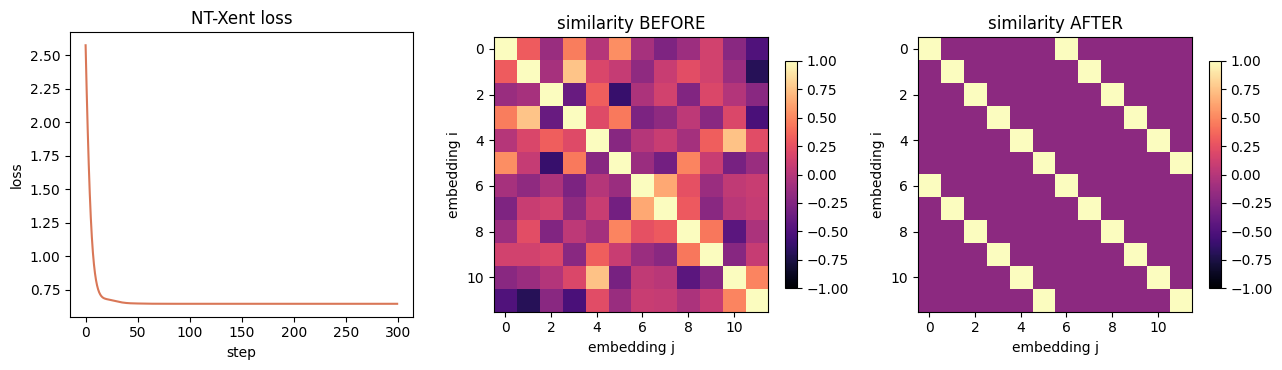

positive pairs sit at offset +/-B off the diagonal; they brighten to ~+1 after training.


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(losses, color='#d97757'); ax[0].set_title('NT-Xent loss')
ax[0].set_xlabel('step'); ax[0].set_ylabel('loss')

for a, S, ttl in [(ax[1], S_before, 'similarity BEFORE'), (ax[2], S_after, 'similarity AFTER')]:
    im = a.imshow(S, cmap='magma', vmin=-1, vmax=1)
    a.set_title(ttl); a.set_xlabel('embedding j'); a.set_ylabel('embedding i')
    fig.colorbar(im, ax=a, shrink=0.8)
plt.tight_layout(); plt.show()
print('positive pairs sit at offset +/-B off the diagonal; they brighten to ~+1 after training.')

## 4 · Read the positive-pair similarity directly

For each of the $2B$ rows, the positive partner's cosine similarity should climb toward $+1$ after optimisation.

In [6]:
idx = (np.arange(2 * B) + B) % (2 * B)               # partner indices
pos_before = S_before[np.arange(2 * B), idx]
pos_after  = S_after[np.arange(2 * B), idx]
print('mean positive-pair cosine  before =', round(pos_before.mean(), 3))
print('mean positive-pair cosine  after  =', round(pos_after.mean(), 3), ' (-> ~1.0)')

mean positive-pair cosine  before = 0.026
mean positive-pair cosine  after  = 1.0  (-> ~1.0)


## Takeaway

- InfoNCE / NT-Xent is a **softmax cross-entropy** where the positive pair is the "correct class" among all in-batch candidates.
- Temperature $\tau$ sharpens the softmax; smaller $\tau$ punishes hard negatives more.
- Minimising the loss **pulls the two views of each item together** (cosine $\to 1$) and **pushes different items apart** — structure learned with no labels. The hand-worked anchor ($\approx 0.239$) is the same formula the batch loss runs at scale.